# Unemployment Analysis with Python

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA)
on unemployment data from India. The analysis focuses on understanding
regional and temporal trends in unemployment and examining the impact
of the COVID-19 pandemic on unemployment rates.

### Technologies Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

# Set default figure size
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
df = pd.read_csv("Desktop/Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 754
Number of columns: 7


In [14]:
print("Columns in the dataset:\n")

for column in df.columns:
    print(column)

Columns in the dataset:

Region
 Date
 Frequency
 Estimated Unemployment Rate (%)
 Estimated Employed
 Estimated Labour Participation Rate (%)
Area


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 41.4+ KB


In [30]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [32]:
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

Region                                     14
Date                                       14
Frequency                                  14
Estimated Unemployment Rate (%)            14
Estimated Employed                         14
Estimated Labour Participation Rate (%)    14
Area                                       14
dtype: int64


In [34]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [36]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

print(df["Date"].dtype)

datetime64[ns]


In [40]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

In [42]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Region                                     14
Date                                       14
Frequency                                  14
Estimated Unemployment Rate (%)            14
Estimated Employed                         14
Estimated Labour Participation Rate (%)    14
Area                                       14
dtype: int64

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


## Region-wise Average Unemployment Rate

The following analysis calculates the average unemployment rate
for each state/region. This helps us identify regions where the
average unemployment rate was relatively high during the period.

In [45]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

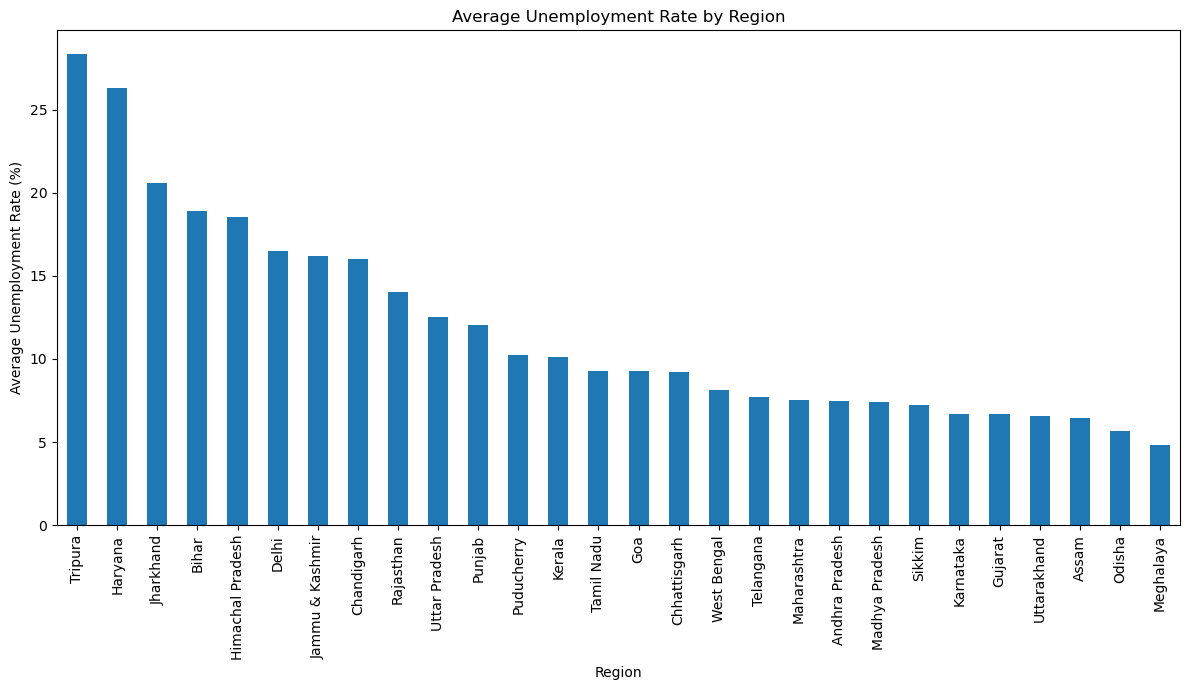

In [47]:
plt.figure(figsize=(12, 7))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Observation

The chart shows that unemployment rates vary considerably across
different regions of India. Some regions have noticeably higher
average unemployment rates than others, indicating differences in
employment conditions across states.

In [50]:
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%B")

df[["Date", "Month", "Month_Name"]].head()

,Date,Month,Month_Name
0,2019-05-31,5,May
1,2019-06-30,6,June
2,2019-07-31,7,July
3,2019-08-31,8,August
4,2019-09-30,9,September


In [52]:
month_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

month_avg

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

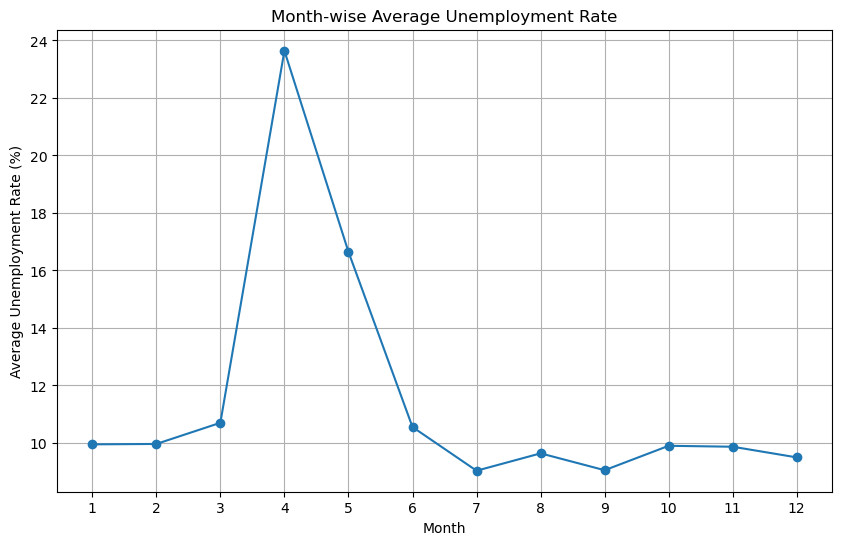

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    month_avg.index,
    month_avg.values,
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

### Observation

The month-wise trend shows how unemployment changed during different
months. The variation indicates that unemployment was not constant
throughout the year and was affected by changes in economic and
employment conditions.

In [57]:
top_regions = df["Region"].value_counts().head(3).index.tolist()

print("Selected regions:", top_regions)

Selected regions: ['Andhra Pradesh', 'Kerala', 'West Bengal']


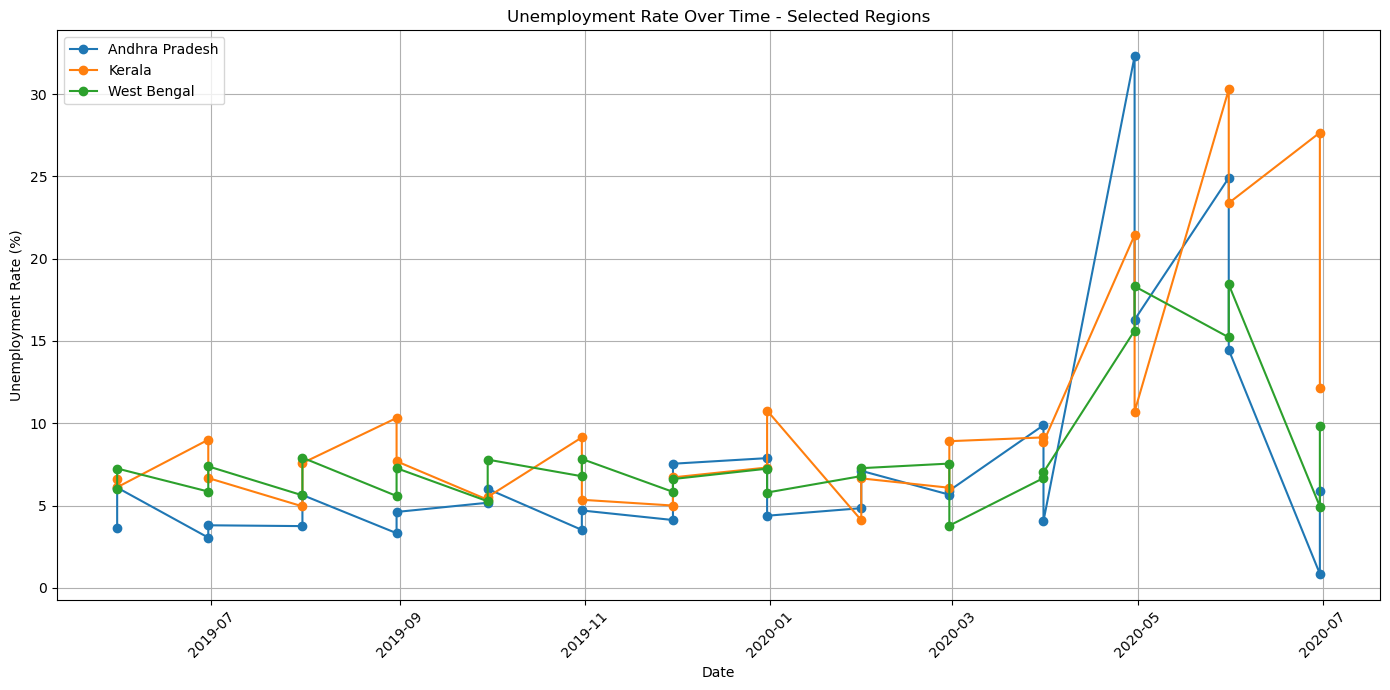

In [59]:
plt.figure(figsize=(14, 7))

for region in top_regions:
    region_data = df[df["Region"] == region].sort_values("Date")
    
    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time - Selected Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The time-series chart shows changes in unemployment rates over time
for three selected regions. A noticeable rise in unemployment can be
observed around the COVID-19 period, although the magnitude of the
change differs between regions.

In [62]:
top_10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

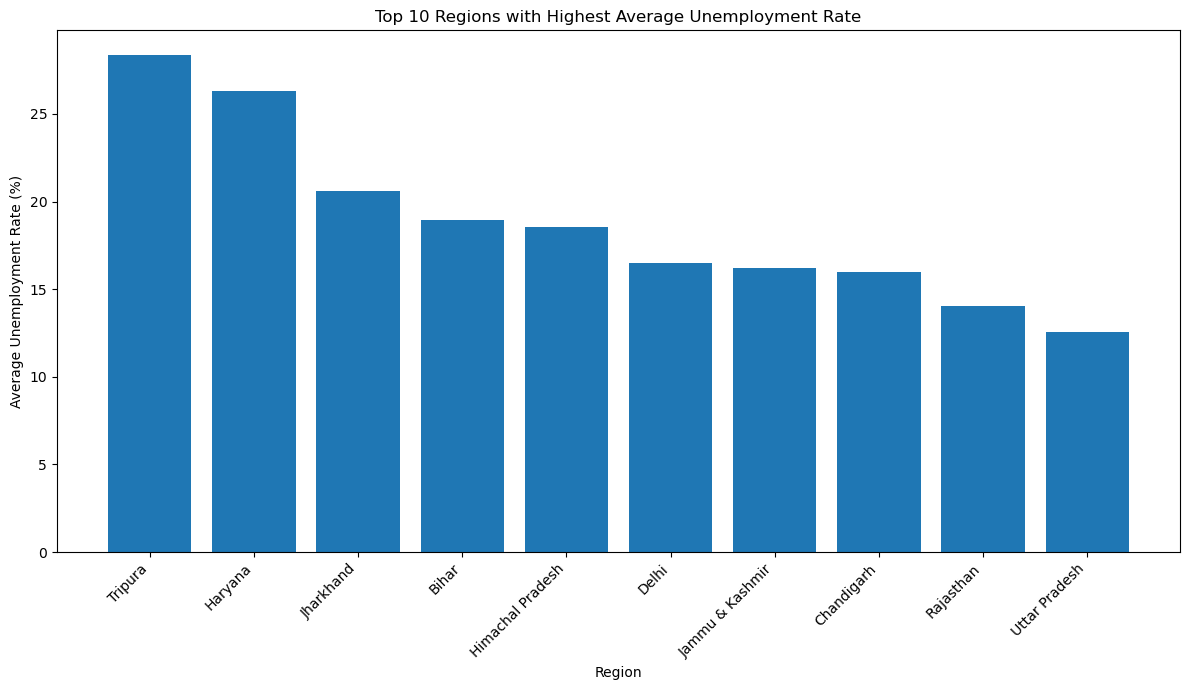

In [64]:
plt.figure(figsize=(12, 7))

plt.bar(top_10.index, top_10.values)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

The bar chart identifies the ten regions having the highest average
unemployment rates in the dataset. These regions experienced
relatively higher unemployment compared with the other regions
during the analyzed period.

In [67]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


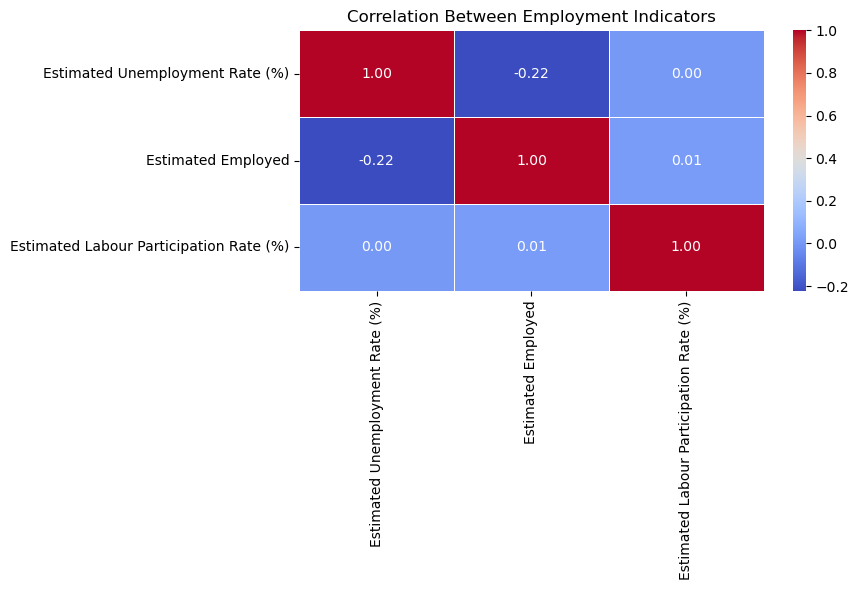

In [69]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Employment Indicators")

plt.tight_layout()
plt.show()

### Observation

The heatmap represents the correlation between unemployment rate,
estimated employment and labour participation rate.

A positive correlation means that both variables tend to increase
together, while a negative correlation indicates that when one
variable increases, the other tends to decrease.

The strength of the relationship can be understood from the
correlation values shown in the heatmap.

In [72]:
pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

print("Pre-COVID records:", len(pre_covid))
print("Post-COVID records:", len(post_covid))

Pre-COVID records: 536
Post-COVID records: 204


In [74]:
pre_covid_mean = pre_covid[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

post_covid_mean = post_covid[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

comparison = pd.DataFrame({
    "Pre-COVID": pre_covid_mean,
    "Post-COVID": post_covid_mean
})

comparison

,Pre-COVID,Post-COVID
Estimated Unemployment Rate (%),9.509534e+00,1.777436e+01
Estimated Employed,7.466028e+06,6.517203e+06
Estimated Labour Participation Rate (%),4.388612e+01,3.933005e+01


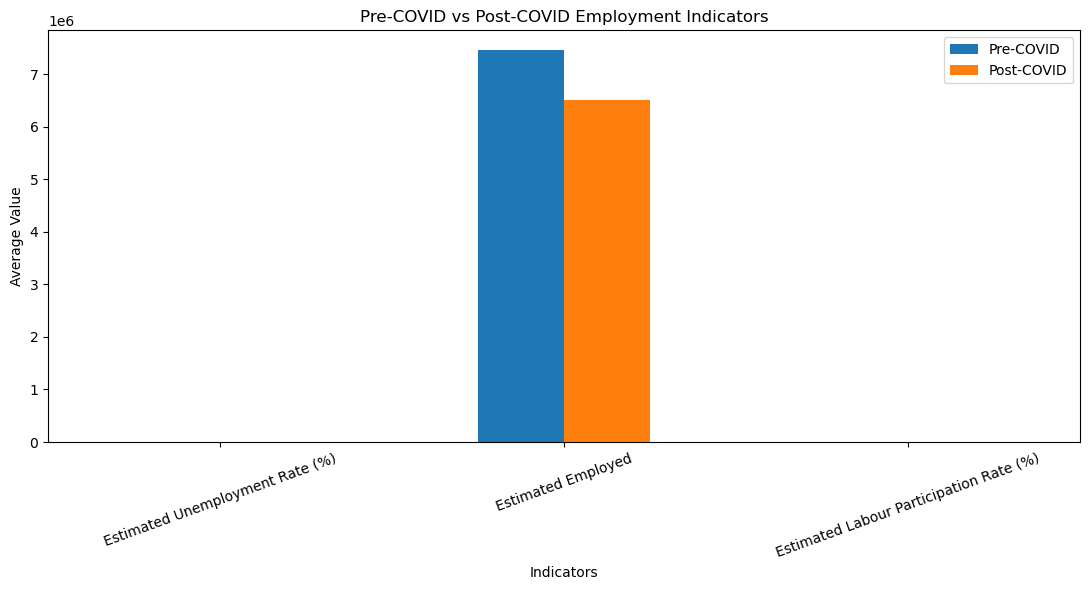

In [76]:
comparison.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Pre-COVID vs Post-COVID Employment Indicators")
plt.xlabel("Indicators")
plt.ylabel("Average Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Observation

The comparison between the pre-COVID and post-COVID periods helps
identify the changes in unemployment, employment and labour
participation.

The COVID-19 pandemic caused major disruptions in economic activity
and employment. The comparison therefore provides an indication of
how employment-related indicators changed during the pandemic period.

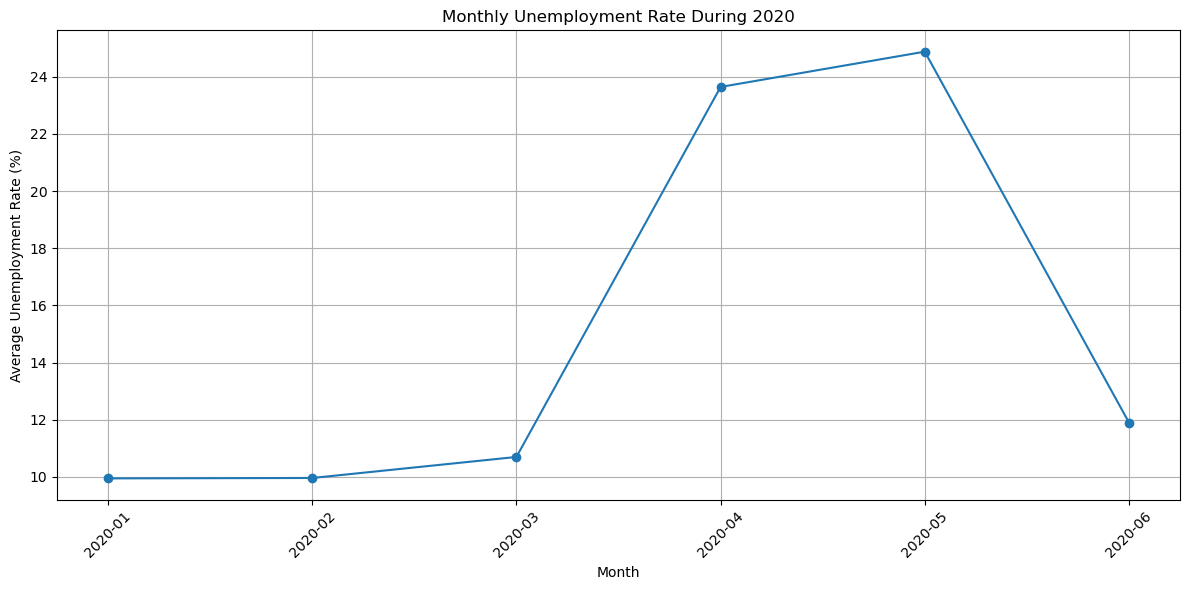

In [79]:
covid_data = df[
    (df["Date"] >= "2020-01-01") &
    (df["Date"] <= "2020-12-31")
]

monthly_covid = (
    covid_data.groupby(covid_data["Date"].dt.to_period("M"))
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_covid.index.astype(str),
    monthly_covid.values,
    marker="o"
)

plt.title("Monthly Unemployment Rate During 2020")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The monthly COVID-19 analysis shows the variation in unemployment
during 2020. The unemployment rate changed substantially during the
pandemic period, reflecting the disruption caused by lockdowns and
reduced economic activity.

# Conclusion

This project analyzed unemployment data from India using Python,
Pandas, Matplotlib and Seaborn. Exploratory Data Analysis was used
to understand regional and temporal variations in unemployment.

The region-wise analysis showed that unemployment rates differed
considerably across states. The time-series analysis demonstrated
that unemployment changed over time, with noticeable variations
during the COVID-19 period.

The correlation heatmap helped analyze the relationship between
unemployment rate, employment and labour participation rate. The
pre-COVID and post-COVID comparison also showed that the pandemic
period had a significant impact on employment-related indicators.

Overall, the analysis provides useful insights into unemployment
patterns in India and demonstrates how data analysis and
visualization can be used to understand real-world economic trends.